In [ ]:
from random import random
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit

def random_number(N):
    secret_number = np.random.randint(1, N+1, size=1)
    return secret_number

def tries_number_adivinator(N):
    secret_number = random_number(N)
    tries = 0
    inferior_limit = 1
    superior_limit = N
    while inferior_limit <= superior_limit:
        tries += 1
        guess = (inferior_limit + superior_limit) // 2
        if guess == secret_number:
            break
        elif guess < secret_number:
            inferior_limit = guess + 1
        else:
            superior_limit = guess - 1
    return tries

tries_number_adivinator(100)

6

In [ ]:
def tries_matrix(N, M):
    tries_matrix = np.zeros((N,M))
    for i in range(1,N+1):
        for j in range(M):
            tries_matrix[i-1,j] = tries_number_adivinator(i)
    return tries_matrix

tries_matrix(100, 1000)

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 2.],
       [1., 1., 1., ..., 2., 2., 1.],
       ...,
       [4., 7., 7., ..., 7., 6., 6.],
       [7., 3., 7., ..., 7., 6., 5.],
       [6., 7., 3., ..., 4., 7., 7.]])

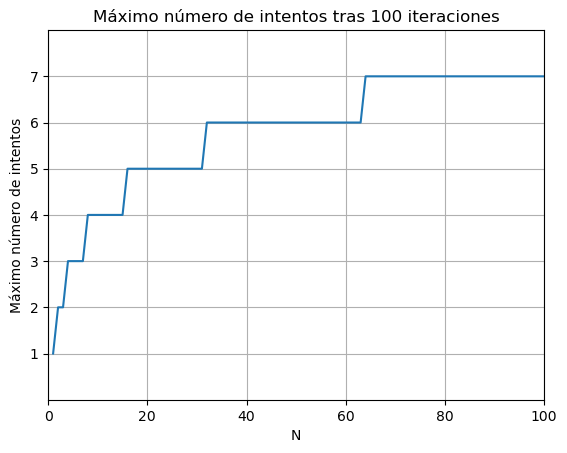

In [ ]:
def maximum_tries(N, M):
    max_tries = np.zeros(N)
    for i in range(1, N+1):
        max_tries[i-1] = np.max(tries_matrix(i, M))
    return max_tries

def plot_max_tries(N, M):
    max_tries = maximum_tries(N, M)
    n = np.array(range(1,N+1))
    plt.plot(n, max_tries)
    plt.xlabel('N')
    plt.ylabel(f'Máximo número de intentos')
    plt.title(f'Máximo número de intentos tras {M} iteraciones')
    plt.xlim(0, N)
    plt.ylim(0, np.max(max_tries) + 1)
    plt.yticks(range(1, int(np.max(max_tries) + 1)))
    plt.grid(True)

plot_max_tries(100, 100)

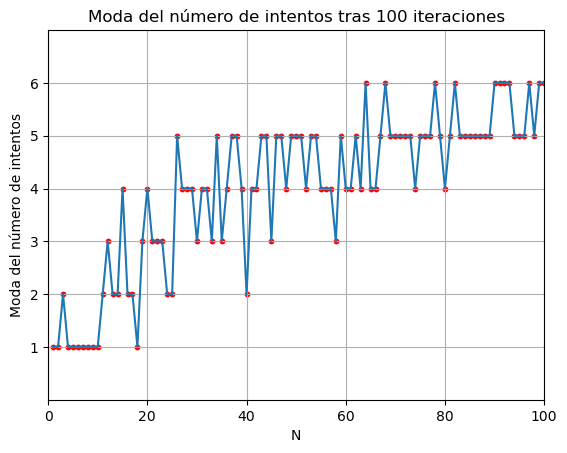

In [ ]:
def mode_tries(N, M):
    mode_tries_result = np.zeros(N)
    for i in range(1, N+1):
        mode_result = stats.mode(tries_matrix(i, M), keepdims=False)
        mode_tries_result[i-1] = mode_result.mode[0]
    return mode_tries_result

def plot_mode_tries(N, M):
    mode_tries_result = mode_tries(N, M)
    n = np.array(range(1,N+1))
    plt.plot(n, mode_tries_result)
    plt.scatter(n, mode_tries_result, s=10, color='r')
    plt.xlabel('N')
    plt.ylabel(f'Moda del número de intentos')
    plt.title(f'Moda del número de intentos tras {M} iteraciones')
    plt.xlim(0, N)
    plt.ylim(0, np.max(mode_tries_result) + 1)
    plt.yticks(range(1, int(np.max(mode_tries_result) + 1)))
    plt.grid(True)

plot_mode_tries(100, 100)

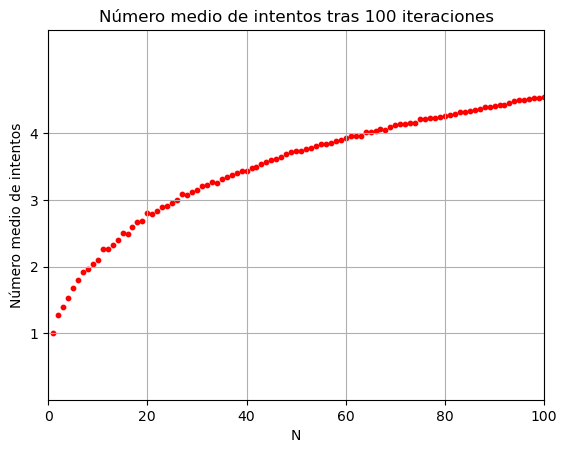

In [ ]:
def mean_tries(N, M):
    mean_tries_result = np.zeros(N)
    for i in range(1, N+1):
        mean_tries_result[i-1] = np.mean(tries_matrix(i, M))
    return mean_tries_result

def plot_mean_tries(N, M):
    mean_tries_result = mean_tries(N, M)
    n = np.array(range(1,N+1))
    #plt.plot(n, mean_tries_result)
    plt.scatter(n, mean_tries_result, s=10, color='r')
    plt.xlabel('N')
    plt.ylabel(f'Número medio de intentos')
    plt.title(f'Número medio de intentos tras {M} iteraciones')
    plt.xlim(0, N)
    plt.ylim(0, np.max(mean_tries_result) + 1)
    plt.yticks(range(1, int(np.max(mean_tries_result) + 1)))
    plt.grid(True)

plot_mean_tries(100, 100)

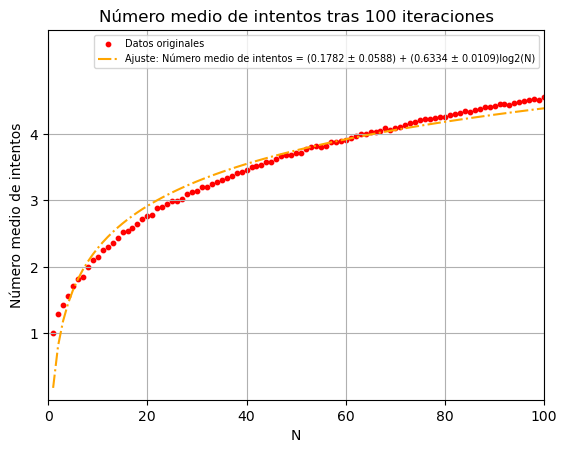

In [ ]:
def function(N, a, b):
    return a + b * np.log2(N)

def mean_fit(N, M):
    mean_tries_result = mean_tries(N, M)
    n = np.array(range(1,N+1))
    popt, pcov = curve_fit(function, n, mean_tries_result)
    a, b = popt
    sigma_a = np.sqrt(pcov[0, 0])
    sigma_b = np.sqrt(pcov[1, 1])
    plt.scatter(n, mean_tries_result, color='r', s=10, label='Datos originales')
    plt.plot(n, function(n, *popt), '-.', color='orange', label=f'Ajuste: Número medio de intentos = ({a:.4f} ± {sigma_a:.4f}) + ({b:.4f} ± {sigma_b:.4f})log2(N)') # Se actualiza la etiqueta
    plt.xlabel('N')
    plt.ylabel(f'Número medio de intentos')
    plt.title(f'Número medio de intentos tras {M} iteraciones')
    plt.legend(fontsize=7)
    plt.grid(True)
    plt.xlim(0, N)
    plt.ylim(0, np.max(mean_tries_result) + 1)
    plt.yticks(range(1, int(np.max(mean_tries_result) + 1)))
    plt.show()

mean_fit(100,100)

La búsqueda binaria divide el espacio de búsqueda por la mitad en cada paso. En el peor de los casos, el número de intentos necesarios para encontrar el número secreto es el número de veces que se puede dividir el rango de números (de 1 a N) por la mitad hasta que quede solo un número.

Este proceso de división repetida por la mitad está directamente relacionado con el logaritmo en base 2. El logaritmo en base 2 de un número N (log₂(N)) nos dice cuántas veces necesitamos dividir N por 2 para llegar a 1.

Por lo tanto, el logaritmo en base 2 es una buena aproximación del número de intentos necesarios en una búsqueda binaria, y por eso se usa en el código para ajustar la curva a los datos.